In [1]:
# pip install pdf2image opencv-python matplotlib numpy
# pdf2image requiere poppler instalado en el sistema (apt install poppler-utils)

from pdf2image import convert_from_path
import cv2
import numpy as np
import matplotlib.pyplot as plt

### Calibration parameters

In [2]:
# PARÁMETROS DE CALIBRACIÓN

DPI_CALIBRACION = 200
BASE_BLOCK_SIZE = 25   # Valor que funcionaba a 200 DPI
BASE_KERNEL_LEN = 120  # Valor que funcionaba a 200 DPI

DPI_LECTURA = 100       # Resolución real
FACTOR_REDUCCION = 0.75  # 1.0 = no reducir, 0.5 = reducir a la mitad la matriz

# Densidad de píxeles real de la matriz FINAL que procesará OpenCV
DPI_EFECTIVO = DPI_LECTURA * FACTOR_REDUCCION

# Proporción es esto comparado con nuestra calibración ideal
RATIO_ESCALA = DPI_EFECTIVO / DPI_CALIBRACION

# Ajustamos los parámetros
block_size_escalado = int(BASE_BLOCK_SIZE * RATIO_ESCALA)
# Forzamos impar y mínimo 3
if block_size_escalado % 2 == 0:
    block_size_escalado += 1
block_size_escalado = max(3, block_size_escalado)

# No puede ser menor a 1
kernel_length = max(1, int(BASE_KERNEL_LEN * RATIO_ESCALA)) 

### Original image loading

Tamaño original leído: (4987, 3539, 3)
(4987, 3539, 3)


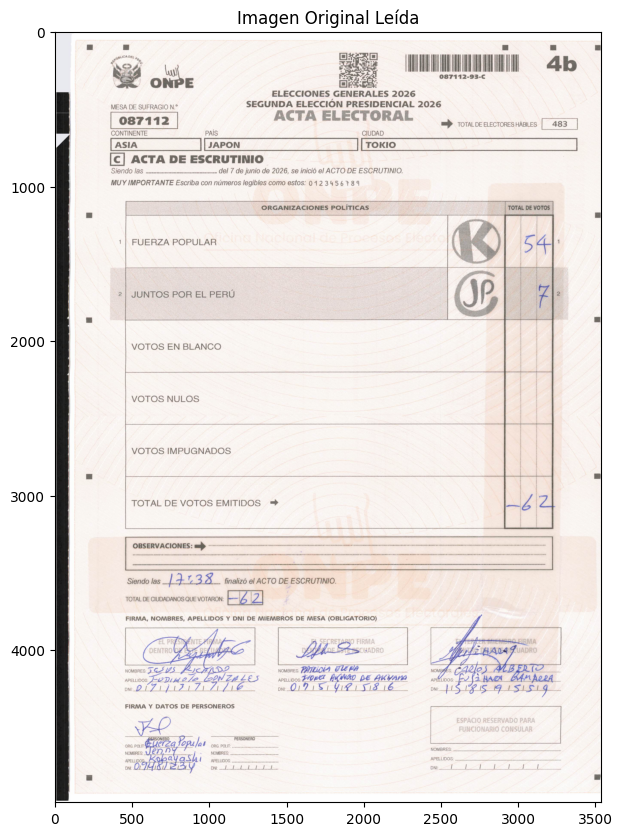

In [3]:
pages = convert_from_path("acta_test3.pdf", dpi=DPI_LECTURA)
img = np.array(pages[0])  # imagen en RGB
img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)  # OpenCV usa BGR
print(f"Tamaño original leído: {img.shape}")

print(img.shape)  # (alto, ancho, canales)
plt.figure(figsize=(8,10))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Imagen Original Leída")
plt.show()

### Binarization

Tamaño reducido a procesar: (3740, 2654)


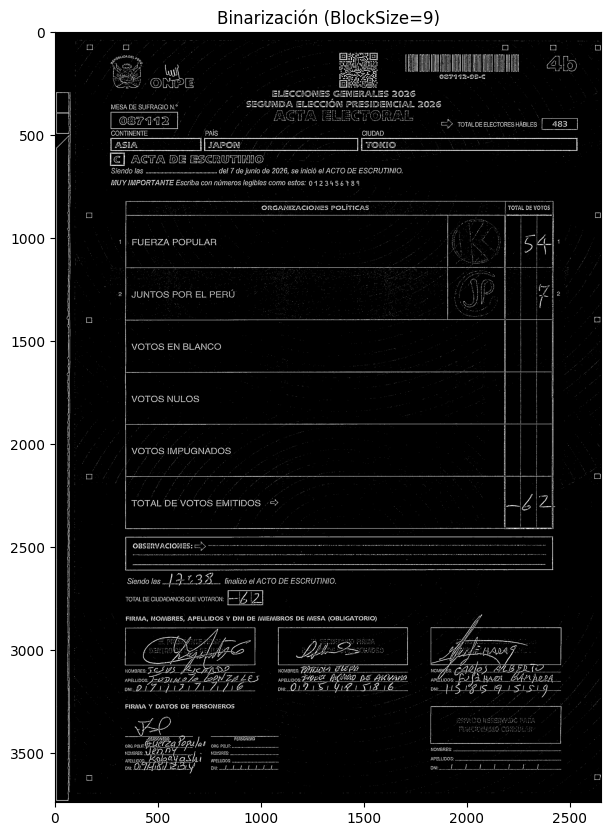

CPU times: user 1.04 s, sys: 159 ms, total: 1.2 s
Wall time: 1.06 s


In [4]:
%%time
gray_orig = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Reducimos la imagen para procesar la geometría mucho más rápido
# INTER_AREA es fundamental para no perder líneas delgadas al reducir
gray = cv2.resize(gray_orig, None, fx=FACTOR_REDUCCION, fy=FACTOR_REDUCCION, interpolation=cv2.INTER_AREA)
print(f"Tamaño reducido a procesar: {gray.shape}")

# Binarización adaptativa: convierte cada píxel a blanco o negro
# según el contraste local (mejor que un umbral fijo para escaneos)
# https://stackabuse.com/opencv-adaptive-thresholding-in-python-with-cv2adaptivethreshold/
binary = cv2.adaptiveThreshold(
    src=gray, maxValue=255,
    # Calcula el umbral local usando una media gaussiana.
    adaptiveMethod=cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    # invertido: líneas = blanco (255), fondo = negro (0)
    thresholdType=cv2.THRESH_BINARY_INV,
    # Tunear en impares
    blockSize=block_size_escalado,
    # Tunear de dos en dos
    C=12 # La C nunca se escala
)

plt.figure(figsize=(8,10))
plt.imshow(binary, cmap='gray')
plt.title(f"Binarización (BlockSize={block_size_escalado})")
plt.show()

### Mathematical Morphology

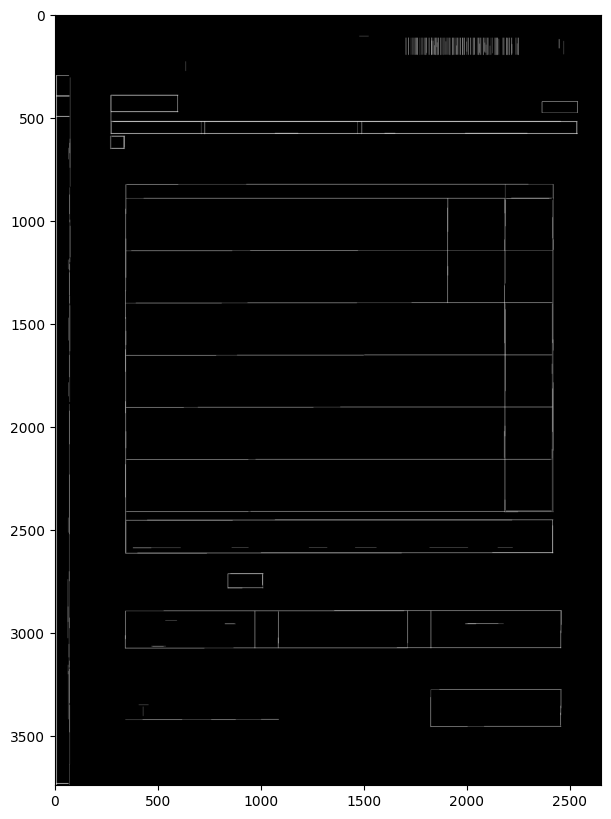

CPU times: user 919 ms, sys: 97.8 ms, total: 1.02 s
Wall time: 1.02 s


In [5]:
%%time
# Morphological operations
# https://www.geeksforgeeks.org/python/python-opencv-morphological-operations/
# https://opencv24-python-tutorials.readthedocs.io/en/latest/py_tutorials/py_imgproc/py_morphological_ops/py_morphological_ops.html
# Kernel horizontal: muy ancho, 1 píxel de alto
# Solo sobrevive lo que es horizontal y largo (líneas de tabla)

# Dimensiones reducidas para calcular el tamaño de nuestras "soldaduras"
h_reduced, w_reduced = binary.shape[:2]

horizontal_kernel = \
    cv2.getStructuringElement(cv2.MORPH_RECT, (kernel_length, 1))
horizontal_lines = \
    cv2.morphologyEx(binary, cv2.MORPH_OPEN, horizontal_kernel)

# Si una firma gigante partió una línea horizontal en dos, la soldamos.
# Usamos un molde largo del 5% del ancho de la página.
soldadura_h = \
        cv2.getStructuringElement(cv2.MORPH_RECT, (int(w_reduced * 0.05), 1))
horizontal_lines = \
        cv2.morphologyEx(horizontal_lines, cv2.MORPH_CLOSE, soldadura_h)

# Kernel vertical: muy alto, 1 píxel de ancho
vertical_kernel = \
        cv2.getStructuringElement(cv2.MORPH_RECT, (1, kernel_length))
vertical_lines = \
        cv2.morphologyEx(binary, cv2.MORPH_OPEN, vertical_kernel)

# Si un sello o tachón rompió una línea vertical, la soldamos.
# Usamos un molde largo del 3% del alto de la página, para que NO fusione la tabla con el encabezado
soldadura_v = \
        cv2.getStructuringElement(cv2.MORPH_RECT, (1, int(h_reduced * 0.03)))
vertical_lines = \
        cv2.morphologyEx(vertical_lines, cv2.MORPH_CLOSE, soldadura_v)

# Combinamos ambas: esto nos da el "esqueleto" de la tabla
table_mask = cv2.add(horizontal_lines, vertical_lines)

plt.figure(figsize=(8,10))
plt.imshow(table_mask, cmap='gray')
plt.show()

### Contour retrieval

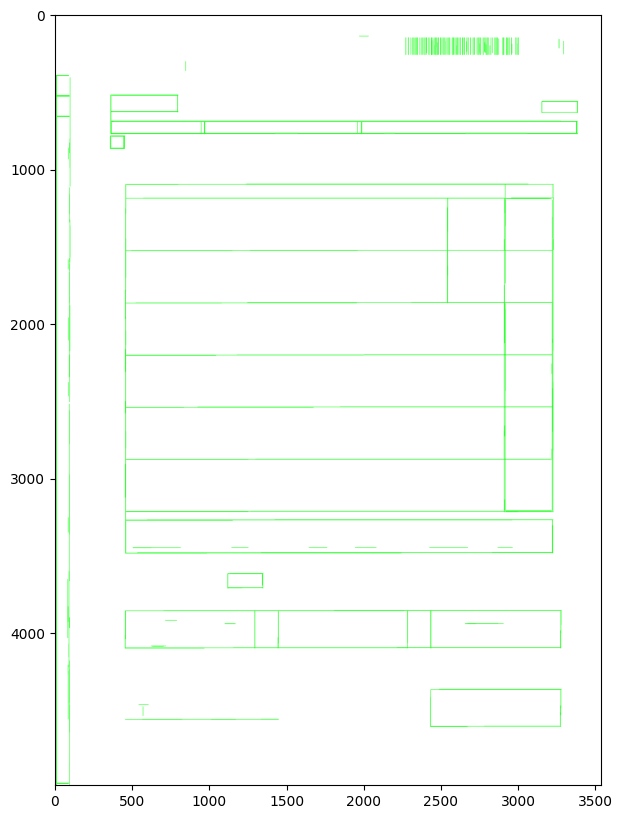

Contornos encontrados: 147


In [6]:
contours, hierarchy = cv2.findContours(table_mask, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE
)

# Escalar matemáticamente todos los puntos de los contornos a la resolución original
# Dividimos entre FACTOR_ESCALA (e.g. dividir entre 0.5 es igual a multiplicar por 2)
# y convertimos a enteros de 32 bits, que es el tipo de dato que exige cv2.drawContours
contours_orig_size = [(c / FACTOR_REDUCCION).astype(np.int32) for c in contours]

# Dibujamos todos los contornos sobre la imagen original para verificar
debug_img = img.copy()

# Creamos un lienzo en blanco (fondo blanco) con las mismas dimensiones que la imagen original
debug_img = np.ones_like(img) * 255
cv2.drawContours(debug_img, contours_orig_size, -1, (0, 255, 0), 2)

plt.figure(figsize=(8,10))
plt.imshow(cv2.cvtColor(debug_img, cv2.COLOR_BGR2RGB))
plt.show()

print(f"Contornos encontrados: {len(contours)}")